# GRU Modeli ile Su Talebi Tahmini

Bu notebook, Malatya günlük su tüketimi verisini kullanarak GRU (Gated Recurrent Unit) modelini eğitir, değerlendirir ve kayıt eder.

## Gerekli Kütüphaneler

In [3]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import joblib

import keras
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout

np.random.seed(42)
keras.utils.set_random_seed(42)
print('✓ Kütüphaneler yüklendi')
print(f'✓ Keras sürümü: {keras.__version__}')
print(f'✓ Backend: {keras.backend.backend()}')


✓ Kütüphaneler yüklendi
✓ Keras sürümü: 3.14.0
✓ Backend: torch


## Veri Yükleme ve Hazırlama

In [4]:
try:
    df_su = pd.read_csv('malatya_gunluk_su_tuketimi_20yil.csv')
    df_yagis = pd.read_csv('malatya_gunluk_yagis_20yil.csv')
    print(f'✓ Su tüketimi veri seti: {df_su.shape}')
    print(f'✓ Yağış veri seti: {df_yagis.shape}')
    print('Su sütunları:', list(df_su.columns))
except FileNotFoundError as e:
    print(f'❌ Dosya bulunamadı: {e}')
    raise

✓ Su tüketimi veri seti: (7305, 4)
✓ Yağış veri seti: (7305, 5)
Su sütunları: ['Tarih', 'Ort_Sicaklik', 'Hafta_Sonu', 'Su_Tuketimi_m3']


In [5]:
def find_date_col(df):
    for c in df.columns:
        if 'tarih' in c.lower() or 'date' in c.lower() or 'zaman' in c.lower():
            return c
    return df.columns[0]

su_date_col = find_date_col(df_su)
yagis_date_col = find_date_col(df_yagis)

df_su = df_su.copy()
df_yagis = df_yagis.copy()
df_su['date'] = pd.to_datetime(df_su[su_date_col], errors='coerce')
df_yagis['date'] = pd.to_datetime(df_yagis[yagis_date_col], errors='coerce')

# Hedef sütunu bul
target_candidates = [c for c in df_su.columns if 'tuketim' in c.lower() or 'consumption' in c.lower() or 'su_' in c.lower()]
if not target_candidates:
    numeric_cols = df_su.select_dtypes(include=[np.number]).columns.tolist()
    target_candidates = numeric_cols
target_col = target_candidates[0]
print(f'✓ Hedef sütun: {target_col}')

df_model = df_su[['date', target_col]].dropna().sort_values('date').reset_index(drop=True)
print(f'✓ Model veri seti: {df_model.shape}')
df_model.head()

✓ Hedef sütun: Su_Tuketimi_m3
✓ Model veri seti: (7305, 2)


,date,Su_Tuketimi_m3
0,2004-01-01,93910
1,2004-01-02,96421
2,2004-01-03,102581
3,2004-01-04,103912
4,2004-01-05,95013


## Veri Görselleştirme

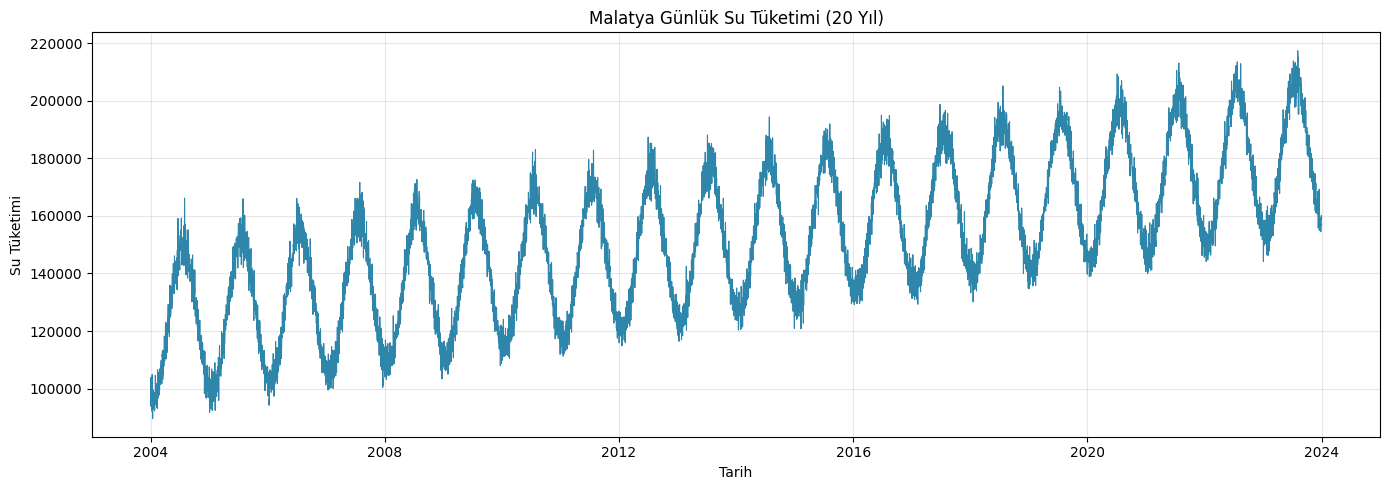

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df_model['date'], df_model[target_col], color='#2E86AB', linewidth=0.8)
plt.xlabel('Tarih')
plt.ylabel('Su Tüketimi')
plt.title('Malatya Günlük Su Tüketimi (20 Yıl)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Veri Normalleştirme

In [7]:
data = df_model[[target_col]].values.astype(float)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

print(f'✓ Veri şekli: {data.shape}')
print(f'✓ Normalleştirilmiş veri aralığı: [{data_scaled.min():.3f}, {data_scaled.max():.3f}]')

✓ Veri şekli: (7305, 1)
✓ Normalleştirilmiş veri aralığı: [0.000, 1.000]


## GRU için Sekans Veri Oluşturma

In [8]:
def create_sequences(data, look_back=60):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:i + look_back, 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

look_back = 60
X, y = create_sequences(data_scaled, look_back=look_back)

# GRU için şekillendirme: (samples, timesteps, features)
X = X.reshape(X.shape[0], X.shape[1], 1)
y = y.reshape(-1, 1)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f'✓ X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'✓ X_test:  {X_test.shape},  y_test:  {y_test.shape}')

✓ X_train: (5796, 60, 1), y_train: (5796, 1)
✓ X_test:  (1449, 60, 1),  y_test:  (1449, 1)


## GRU Modelini Oluşturma ve Derleme

In [9]:
model = Sequential([
    GRU(50, activation='tanh', return_sequences=True, input_shape=(look_back, 1)),
    Dropout(0.2),
    GRU(50, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()
print('\n✓ GRU modeli oluşturuldu ve derlendi')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 50)         │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 50)             │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,551 (95.90 KB)

 Trainable params: 24,551 (95.90 KB)

 Non-trainable params: 0 (0.00 B)


✓ GRU modeli oluşturuldu ve derlendi


## Model Eğitimi

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)
print('\n✓ Model eğitimi tamamlandı')

Epoch 1/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 189ms/step - loss: 0.0082 - mae: 0.0619 - val_loss: 0.0010 - val_mae: 0.0258
Epoch 2/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 199ms/step - loss: 0.0024 - mae: 0.0380 - val_loss: 0.0032 - val_mae: 0.0473
Epoch 3/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 39s 241ms/step - loss: 0.0021 - mae: 0.0362 - val_loss: 0.0013 - val_mae: 0.0286
Epoch 4/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 208ms/step - loss: 0.0019 - mae: 0.0342 - val_loss: 0.0018 - val_mae: 0.0332
Epoch 5/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 203ms/step - loss: 0.0018 - mae: 0.0331 - val_loss: 0.0010 - val_mae: 0.0259
Epoch 6/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 204ms/step - loss: 0.0017 - mae: 0.0321 - val_loss: 0.0016 - val_mae: 0.0315
Epoch 7/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 205ms/step - loss: 0.0016 - mae: 0.0316 - val_loss: 0.0010 - val_mae: 0.0260
Epoch 8/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 208ms/step - loss: 0.0016 - mae: 0.0320 - val_loss: 0.0011 - val_mae: 0.0262
Epoch 9/40
163/163 ━━━━━━━━━━━━━

## Eğitim Eğrileri

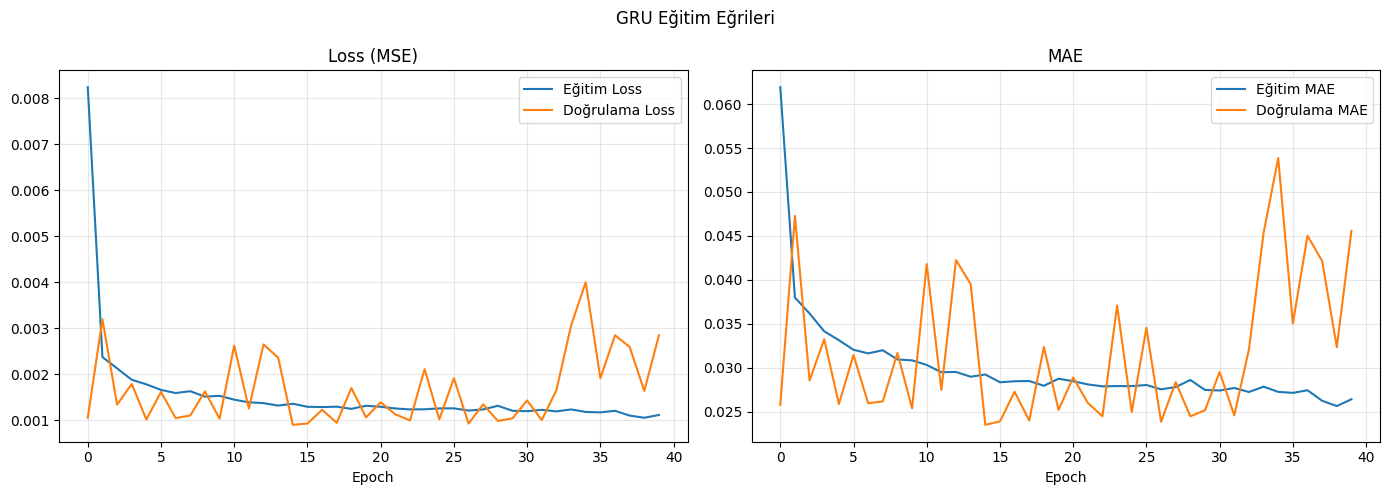

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Eğitim Loss')
axes[0].plot(history.history['val_loss'], label='Doğrulama Loss')
axes[0].set_title('Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'], label='Eğitim MAE')
axes[1].plot(history.history['val_mae'], label='Doğrulama MAE')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('GRU Eğitim Eğrileri')
plt.tight_layout()
plt.show()

## Model Değerlendirmesi

In [12]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Gerçek değerlere dönüştür
y_train_orig = scaler.inverse_transform(y_train)
y_train_pred_orig = scaler.inverse_transform(y_train_pred)

y_test_orig = scaler.inverse_transform(y_test)
y_test_pred_orig = scaler.inverse_transform(y_test_pred)

metrics = {
    'Eğitim': {
        'MAE': mean_absolute_error(y_train_orig, y_train_pred_orig),
        'RMSE': np.sqrt(mean_squared_error(y_train_orig, y_train_pred_orig)),
        'R2': r2_score(y_train_orig, y_train_pred_orig),
        'MAPE': mean_absolute_percentage_error(y_train_orig, y_train_pred_orig)
    },
    'Test': {
        'MAE': mean_absolute_error(y_test_orig, y_test_pred_orig),
        'RMSE': np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig)),
        'R2': r2_score(y_test_orig, y_test_pred_orig),
        'MAPE': mean_absolute_percentage_error(y_test_orig, y_test_pred_orig)
    }
}

print('=== GRU MODEL PERFORMANS METRİKLERİ ===')
for split, m in metrics.items():
    print(f'\n{split}:')
    print(f'  MAE : {m["MAE"]:.4f}')
    print(f'  RMSE: {m["RMSE"]:.4f}')
    print(f'  R²  : {m["R2"]:.4f}')
    print(f'  MAPE: {m["MAPE"]:.2%}')

182/182 ━━━━━━━━━━━━━━━━━━━━ 22s 121ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step
=== GRU MODEL PERFORMANS METRİKLERİ ===

Eğitim:
  MAE : 4458.5437
  RMSE: 5536.3687
  R²  : 0.9422
  MAPE: 2.98%

Test:
  MAE : 6694.8242
  RMSE: 7680.8859
  R²  : 0.8389
  MAPE: 3.73%


## Tahminleri Görselleştirme

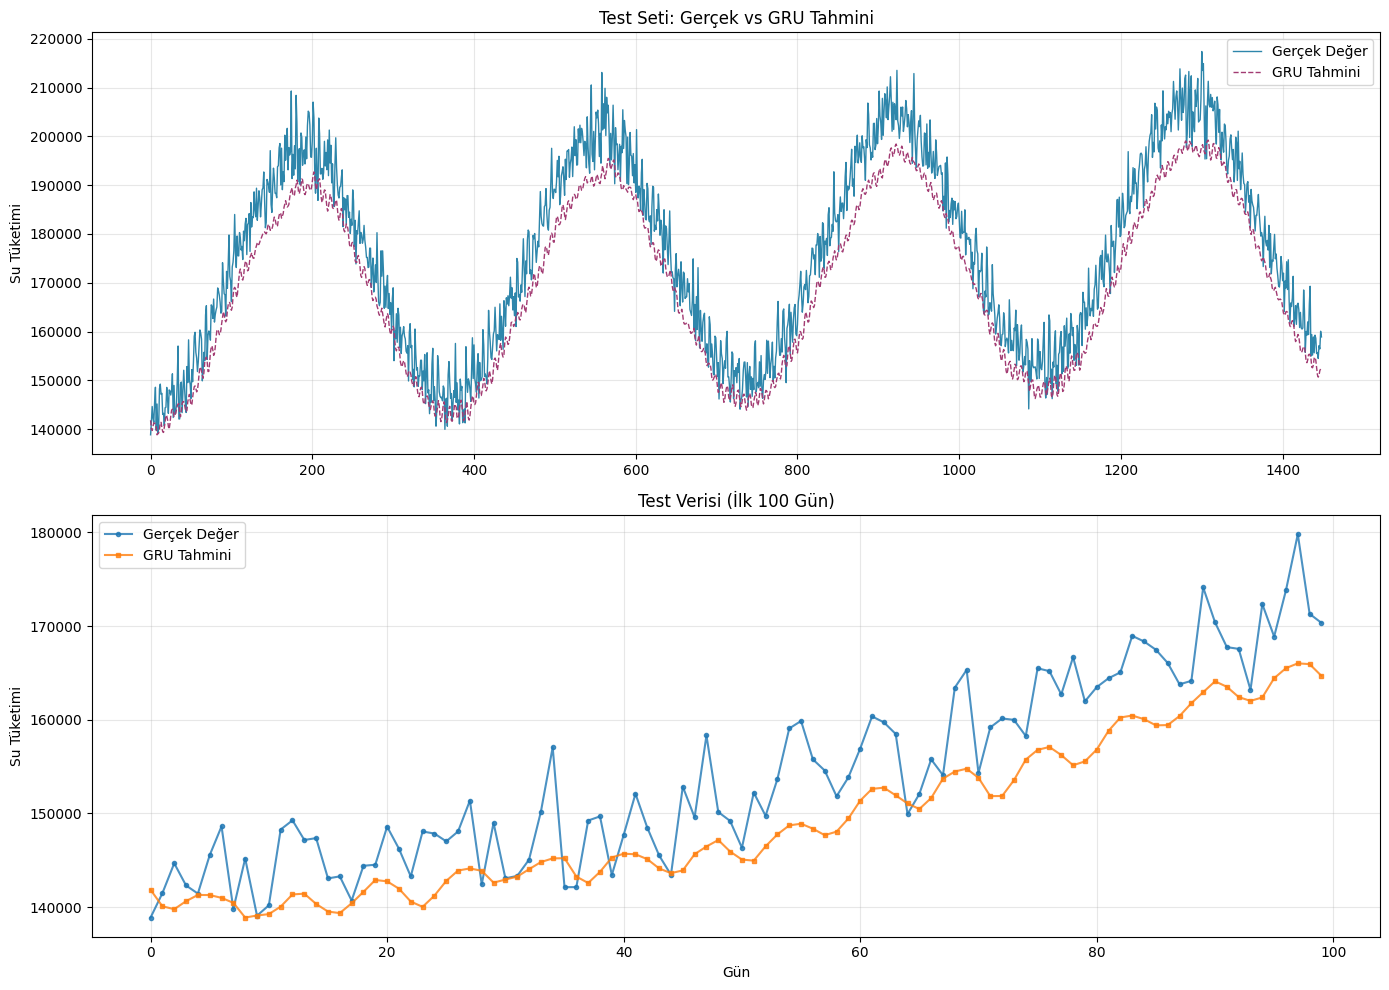

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(y_test_orig, label='Gerçek Değer', color='#2E86AB', linewidth=1)
axes[0].plot(y_test_pred_orig, label='GRU Tahmini', color='#A23B72', linewidth=1, linestyle='--')
axes[0].set_title('Test Seti: Gerçek vs GRU Tahmini')
axes[0].set_ylabel('Su Tüketimi')
axes[0].legend()
axes[0].grid(alpha=0.3)

n = min(100, len(y_test_orig))
axes[1].plot(y_test_orig[:n], label='Gerçek Değer', marker='o', markersize=3, alpha=0.8)
axes[1].plot(y_test_pred_orig[:n], label='GRU Tahmini', marker='s', markersize=3, alpha=0.8)
axes[1].set_title(f'Test Verisi (İlk {n} Gün)')
axes[1].set_xlabel('Gün')
axes[1].set_ylabel('Su Tüketimi')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Gerçek vs Tahmin Scatter Plot

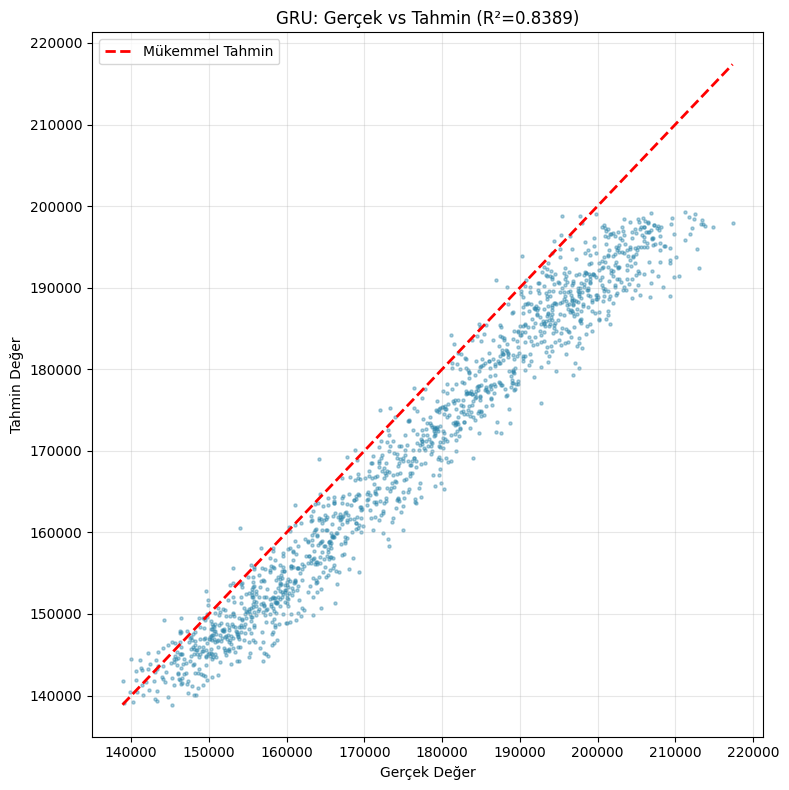

In [14]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test_orig, y_test_pred_orig, alpha=0.4, color='#2E86AB', s=5)
min_val = min(y_test_orig.min(), y_test_pred_orig.min())
max_val = max(y_test_orig.max(), y_test_pred_orig.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Mükemmel Tahmin')
plt.xlabel('Gerçek Değer')
plt.ylabel('Tahmin Değer')
plt.title(f'GRU: Gerçek vs Tahmin (R²={metrics["Test"]["R2"]:.4f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Model ve Scaler Kaydetme

In [16]:
try:
    model.save('gru_su_tahmin_modeli.keras')
    joblib.dump(scaler, 'gru_scaler.joblib')
    joblib.dump({
        'look_back': look_back,
        'target_col': target_col,
        'metrics': metrics
    }, 'gru_model_info.joblib')
    print('✓ Model kaydedildi: gru_su_tahmin_modeli.keras')
    print('✓ Scaler kaydedildi: gru_scaler.joblib')
    print('✓ Model bilgileri kaydedildi: gru_model_info.joblib')
except Exception as e:
    print(f'❌ Kaydetme hatası: {e}')


✓ Model kaydedildi: gru_su_tahmin_modeli.keras
✓ Scaler kaydedildi: gru_scaler.joblib
✓ Model bilgileri kaydedildi: gru_model_info.joblib
